<a href="https://colab.research.google.com/github/CiaraFarrellSETU/phd/blob/main/turloughs_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Notebook:  
Performs a comprehensive hydrological analysis of the Ballygalda Turlough water level data.

1.Data Loading and Preprocessin  
2.Basic Data Exploration  
3.Trend and Seasonal Analysis  
4.Event Identification  
5.Statistical Trend Testing  
6.Return Period Analysis  
7.Recession Analysis  
8.Comparative and Phenological Analysis

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import linregress
import pymannkendall as mk
import datetime

ModuleNotFoundError: No module named 'pymannkendall'

In [2]:
# Ensure pymannkendall is installed and imported
try:
    import pymannkendall as mk
except ModuleNotFoundError:
    print("pymannkendall not found. Installing...")
    !pip install pymannkendall
    import pymannkendall as mk # Re-import after installation

pymannkendall not found. Installing...


In [3]:
# Replace with the actual path to CSV file
file_path = '/content/Ballygalda Turlough-2021-01-01-2026-04-07.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print("CSV file read successfully!")
    # Display the first few rows of the DataFrame
    print(df.head())
    #errors incase issues with file
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_path}' is empty.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

CSV file read successfully!
             Date/Time  Stage (mAOD)  log_elev (mAOD)                 name  \
0  2021-01-01 01:00:00         49.39             46.7  Ballygalda Turlough   
1  2021-01-01 02:00:00         49.39             46.7  Ballygalda Turlough   
2  2021-01-01 03:00:00         49.39             46.7  Ballygalda Turlough   
3  2021-01-01 04:00:00         49.39             46.7  Ballygalda Turlough   
4  2021-01-01 05:00:00         49.39             46.7  Ballygalda Turlough   

     code  
0  GSI_10  
1  GSI_10  
2  GSI_10  
3  GSI_10  
4  GSI_10  


In [4]:
# Data Loading & Initial Inspection
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46133 entries, 0 to 46132
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date/Time        46133 non-null  object 
 1   Stage (mAOD)     46107 non-null  float64
 2   log_elev (mAOD)  46107 non-null  float64
 3   name             46133 non-null  object 
 4   code             46133 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.8+ MB
None


In [5]:
#column names
print(df.columns)

Index(['Date/Time', 'Stage (mAOD)', 'log_elev (mAOD)', 'name', 'code'], dtype='object')


In [6]:
#checking for NAN vlaues
print(df.isnull().sum())

Date/Time           0
Stage (mAOD)       26
log_elev (mAOD)    26
name                0
code                0
dtype: int64


In [7]:
#Ensure Date/Time is converted to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

# Drop any rows where the date couldn't be parsed (safety check)
df = df.dropna(subset=['Date/Time'])

# Set'Date/Time' column as the DataFrame's index
df.set_index('Date/Time', inplace=True)

# Sort the index (Required for time-interpolation) in chronological order
df = df.sort_index()

# Now perform the interpolation unction estimates and fills in NaN (missing) values based on the time difference between the valid data points
df['Stage (mAOD)'] = df['Stage (mAOD)'].interpolate(method='time')

#prints a confirmation message and shows the data type of the DataFrame's index, verifying that it is now a datetime index.
print("Interpolation successful. New Index Type:", type(df.index))

Interpolation successful. New Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [8]:
# Sampling Rate Check: calculates the difference between consecutive timestamps
time_diffs = df.index.to_series().diff().dropna()
print(f"\nMedian Sampling Interval: {time_diffs.median()}")

#if gives Median Sampling Interval: 0 days 01:00:00 : dataset is hourly


Median Sampling Interval: 0 days 01:00:00


In [9]:
#basic statistical summary on the 'Stage (mAOD)' column of  DataFrame
stats = df['Stage (mAOD)'].describe()
print("\n--- Summary Statistics ---")
print(stats)


--- Summary Statistics ---
count    46133.000000
mean        48.274909
std          1.052197
min         46.620000
25%         47.500000
50%         48.350000
75%         49.150000
max         50.010000
Name: Stage (mAOD), dtype: float64


Count: sample size  
Mean: the average water level, if it sits very close to median (50th percentile). It suggests the data is relatively symmetrical and hasn't been heavily skewed by extreme outliers.  
Standard Deviation (std): how consistent the water levels are  
25% & 75%: upper and lower quartiles  

In [10]:
#calculates moving averages of the 'Stage (mAOD)' column and adds them as new columns to your DataFrame:

#consider all observations within each 30-day period
df['30D_MA'] = df['Stage (mAOD)'].rolling(window='30D').mean()

#365-day moving average, smooth out seasonal variations and reveal the underlying long-term trend in the water levels.
#The 365-day moving average is often considered a baseline or long-term trend indicator in hydrological data
df['365D_MA'] = df['Stage (mAOD)'].rolling(window='365D').mean()

## **Plotting Data**

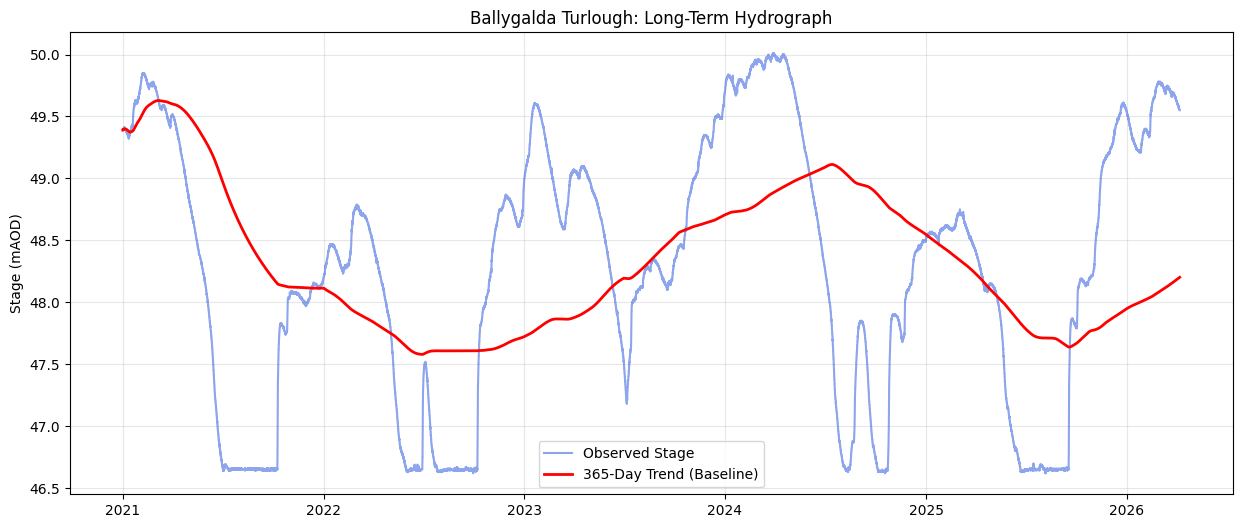

In [11]:
#a long-term hydrograph, visualizing the observed water stage alongside its 365-day moving average.
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Stage (mAOD)'], label='Observed Stage', color='royalblue', alpha=0.6)
plt.plot(df.index, df['365D_MA'], label='365-Day Trend (Baseline)', color='red', linewidth=2)
plt.title('Ballygalda Turlough: Long-Term Hydrograph')
plt.ylabel('Stage (mAOD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* When the stage hits ~46.6m, the turlough is effectively dry. The statistics show that the 25th percentile (47.50m) is very close to this base, confirming it stays dry or very shallow for significant portions of the year
* The red line represents the 365-day moving average, which smooths out the flashy winter floods to show the long-term storage trend  
* Notice that 2024 was an exceptionally "wet" year for this site, as the observed stage stayed near the 50m mark for a prolonged period, pushing the red baseline upward
* The blue line shows very sharp, steep rises and falls. This is typical of karst hydrology



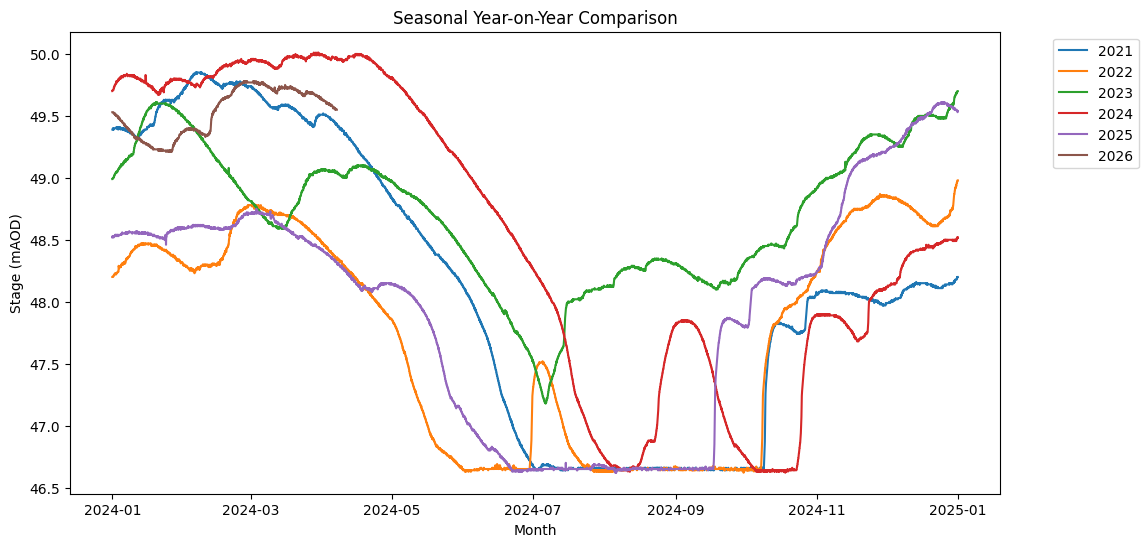

In [12]:
#prepares and then visualizes the water level data for a seasonal year-on-year comparison

df['Year'] = df.index.year
df['DayOfYear'] = df.index.dayofyear
# Create a dummy date for plotting all years on one axis, all dates share the same year,
#overlay the water level data from different actual years on a single plot, making it easy to compare their seasonal patterns without the long-term trend
df['DummyDate'] = pd.to_datetime('2024-' + df.index.strftime('%m-%d %H:%M:%S'), errors='coerce')

plt.figure(figsize=(12, 6))
for year in df['Year'].unique():
    year_data = df[df['Year'] == year]
    plt.plot(year_data['DummyDate'], year_data['Stage (mAOD)'], label=str(year))

plt.title('Seasonal Year-on-Year Comparison')
plt.xlabel('Month')
plt.ylabel('Stage (mAOD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

* Seasonal overlay reveals exactly how Turlough behaves over the years.
* Comparing the years side-by-side highlights just how abnormal 2024 (the red line) was compared to the others
* Late Recession: In almost every other year, the turlough starts its steep drain-down between March and May. In 2024, it held a maximum stage of ~50.0m all the way until June.
* The  Dry Period: Most years hit the 46.62m "floor" by July and stay there until October/November. In 2024, it didn't hit the floor until August
* Hydrological Stress: The red line staying so high for so long suggests that the groundwater table was saturated, preventing the usual "drainage" through the karst fissures
* Uniform Decline: the lines during the emptying phase (e.g., May to July) are similar across 2021, 2022, and 2025
* The small "blip" in July 2022 (orange) shows a flash summer flood that was quickly swallowed back down.
* The refill phase is much more erratic than the drainage phase. In 2023 (green) and 2025 (purple), the turlough refilled aggressively and early.

/tmp/ipykernel_794/2470999424.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_2025[df_2025['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))


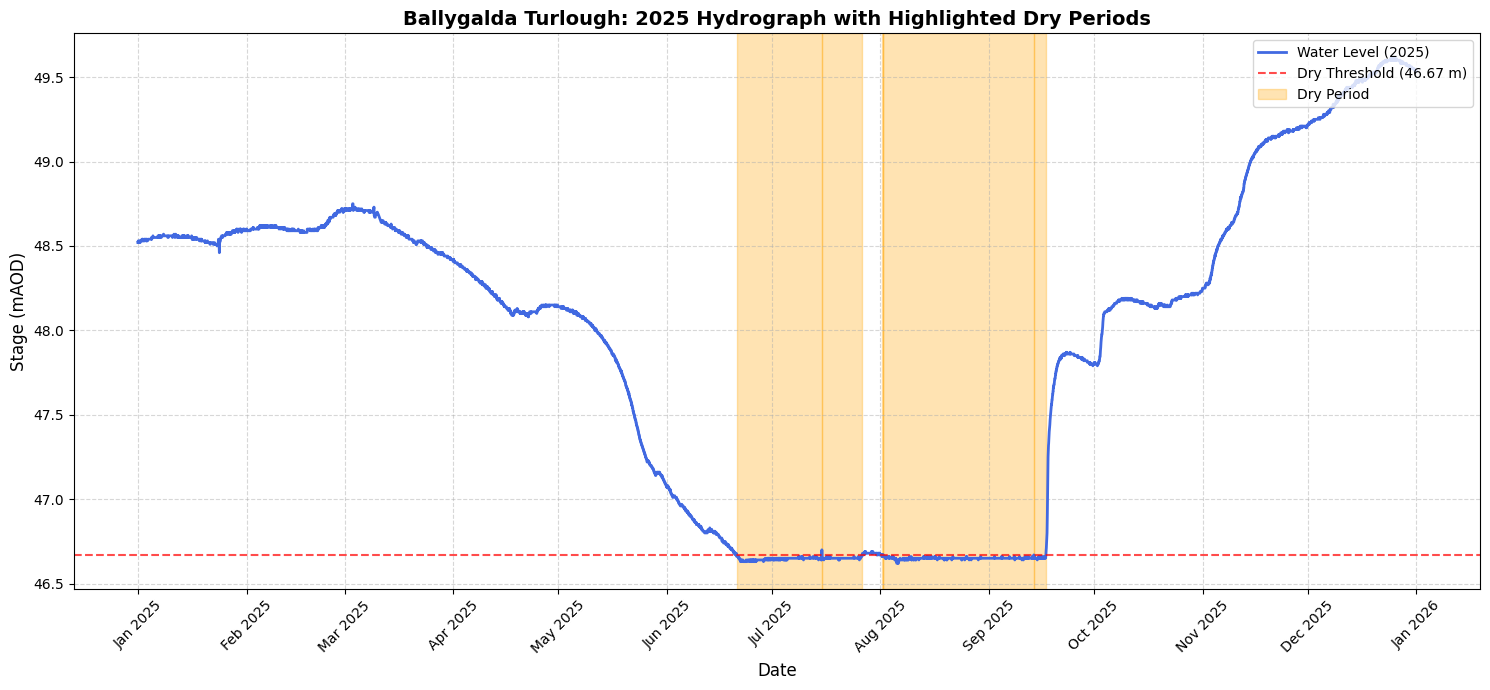

In [13]:
#2025 dry period
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter for the year 2025
df_2025 = df.loc['2025-01-01':'2025-12-31'].copy()

# Define the dry threshold (based on entire dataset minimum)
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df_2025['is_dry'] = df_2025['Stage (mAOD)'] <= dry_threshold

#  Identify start and end dates for shading
# We group the 'is_dry' True blocks
df_2025['block'] = (df_2025['is_dry'] != df_2025['is_dry'].shift()).cumsum()
dry_blocks = df_2025[df_2025['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))

# Create the Plot
plt.figure(figsize=(15, 7))

# Plot the water level line
plt.plot(df_2025.index, df_2025['Stage (mAOD)'], color='royalblue', label='Water Level (2025)', linewidth=2)

# Plot the threshold line
plt.axhline(y=dry_threshold, color='red', linestyle='--', alpha=0.7, label=f'Dry Threshold ({dry_threshold:.2f} m)')

# Highlight the dry periods with shading
is_first_span = True
for start, end in dry_blocks:
    plt.axvspan(start, end, color='orange', alpha=0.3, label='Dry Period' if is_first_span else "")
    is_first_span = False

# Formatting the chart
plt.title('Ballygalda Turlough: 2025 Hydrograph with Highlighted Dry Periods', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Improve x-axis date visibility
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

* Two distinct phases of dryness:
* Phase 1 (Late June - Late July): The turlough hits the floor after a very steady, linear recession starting in April.
* Phase 2 (August – Mid-September): The basin returns to its base level for roughly 6 weeks.
* The "Flash" Refill (Late September): Notice how violent the refill is compared to the drainage. It takes roughly 3 months to empty (April to June), but it gains over a meter in just one week in late September.

/tmp/ipykernel_794/218679284.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_yr[df_yr['is_dry']].groupby('block').apply(lambda x: (x['dummy_date'].min(), x['dummy_date'].max()))
/tmp/ipykernel_794/218679284.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_yr[df_yr['is_dry']].groupby('block').apply(lambda x: (x['dummy_date'].min(), x['dummy_date'].max()))


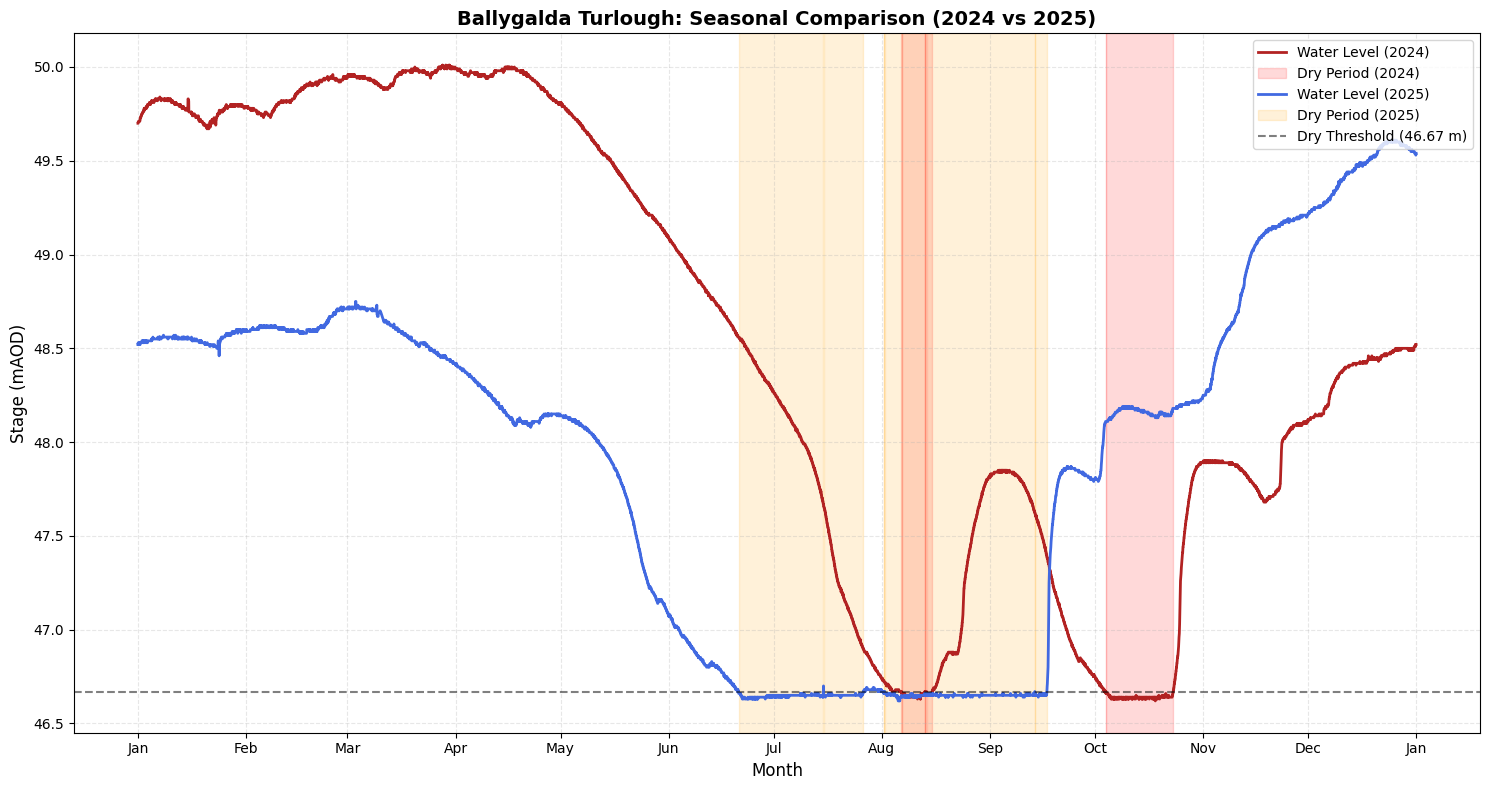

In [14]:
#comparing dry periods from 2 years

#  Filter for the two years
years_to_compare = [2024, 2025]
colors = {2024: 'firebrick', 2025: 'royalblue'}
shading_colors = {2024: 'red', 2025: 'orange'}

# Define threshold (using your logic)
dry_threshold = df['Stage (mAOD)'].min() + 0.05

plt.figure(figsize=(15, 8))

for yr in years_to_compare:
    # Filter and create a copy to avoid SettingWithCopyWarning
    df_yr = df[df.index.year == yr].copy()

    # Create a "Dummy Date" (shifting everything to year 2000) for shared X-axis
    df_yr['dummy_date'] = df_yr.index.map(lambda x: x.replace(year=2000))

    # Identify dry blocks for this specific year
    df_yr['is_dry'] = df_yr['Stage (mAOD)'] <= dry_threshold
    df_yr['block'] = (df_yr['is_dry'] != df_yr['is_dry'].shift()).cumsum()

    # Plot the water level line
    plt.plot(df_yr['dummy_date'], df_yr['Stage (mAOD)'],
             color=colors[yr], label=f'Water Level ({yr})', linewidth=2)

    # Highlight the dry periods with shading
    dry_blocks = df_yr[df_yr['is_dry']].groupby('block').apply(lambda x: (x['dummy_date'].min(), x['dummy_date'].max()))

    is_first_span = True
    for start, end in dry_blocks:
        plt.axvspan(start, end, color=shading_colors[yr], alpha=0.15,
                    label=f'Dry Period ({yr})' if is_first_span else "")
        is_first_span = False

# Plot the threshold line
plt.axhline(y=dry_threshold, color='black', linestyle='--', alpha=0.5, label=f'Dry Threshold ({dry_threshold:.2f} m)')

# Formatting the chart
plt.title(f'Ballygalda Turlough: Seasonal Comparison ({years_to_compare[0]} vs {years_to_compare[1]})',
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

# Improve x-axis to show only months (since years are aligned)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

Comparision of 2025 and 2024 dry periods
* the drainage slopes are almost parallel. This confirms that the drainage capacity of the karst system is constant. 2024 took longer to dry simply because it started from a much higher elevation (50m vs 48.7m). It had more "head" of water to push through the same sized underground holes
* The August 2024 Anomaly: That red "mountain" in August/September. It shows a massive late-summer recharge event that completely erased the start of the dry season. For the plants and insects at the bottom of the basin, 2024 was likely a very difficult year because their "dry" window was essentially gone until October

* Recession: 2024 - mid april , 2025 - march
* First dry period: 2024 - early august, 2025 - late june
* Interuptions: 2024 - huge jump mid auguts, 2025 - tiny late july
* 2nd dry period: 2024 - late october, 2025 - august to mid september

In [15]:
import pandas as pd

# Setup Thresholds
# Using your logic: absolute minimum + 5cm buffer
dry_threshold = df['Stage (mAOD)'].min() + 0.05

# Resample to Daily Frequency
# We use the daily mean to represent the 'state' of the turlough for that day
daily_data = df['Stage (mAOD)'].resample('D').mean()

# Create Boolean Mask for Dry Days
# A value of True means the day was "Dry"
is_dry = daily_data <= dry_threshold

# Calculation: Yearly Breakdown
# Filters for dry days only, then groups by year and counts
dry_days_per_year = is_dry[is_dry].groupby(is_dry[is_dry].index.year).count()

# Calculation: Longest Continuous Dry Spell
# Uses a 'diff-sum' approach to group consecutive True values
dry_blocks = is_dry.ne(is_dry.shift()).cumsum()
# Only look at blocks where is_dry was True, count them, and find the max
longest_dry_spell = is_dry[is_dry].groupby(dry_blocks).count().max()

# Summary Output
print("-" * 30)
print("BALLYGALDA TURLOUGH: DRY PERIOD ANALYSIS")
print("-" * 30)
print(f"Dry Threshold:        {dry_threshold:.2f} mAOD")
print(f"Total Data Range:     {daily_data.index.min().date()} to {daily_data.index.max().date()}")
print(f"Total Dry Days:       {is_dry.sum()} days")
print(f"Longest Dry Spell:    {longest_dry_spell} consecutive days")
print("\nDry Days per Calendar Year:")
print(dry_days_per_year.to_string())
print("-" * 30)

------------------------------
BALLYGALDA TURLOUGH: DRY PERIOD ANALYSIS
------------------------------
Dry Threshold:        46.67 mAOD
Total Data Range:     2021-01-01 to 2026-04-07
Total Dry Days:       313 days
Longest Dry Spell:    92 consecutive days

Dry Days per Calendar Year:
Date/Time
2021     96
2022    106
2024     28
2025     83
------------------------------


* 2024 drop to just 28 dry days compared to the 106 days in 2022 shows just how extreme that particular year was. 2024 had roughly 75% fewer dry days than 2022
* 2023 was a "wet summer" year where the water level fluctuated but never actually dipped below 46.67m threshold
* The fact that 2021, 2022, and 2025 all hover between 80 and 106 days suggests that the "natural" state for Ballygalda is to be dry for roughly 3 months of the year
* Interesting to see if 2026 follows the 2024 trend (short dry period) or the 2025 trend (long dry period).
* 2022 longest dry period: 2022 saw record-breaking temperatures in July and August across Ireland.


## **Flood analysis**

In [18]:

# Find peaks with a minimum height and distance (e.g., 30 days apart)
peaks, _ = find_peaks(df['Stage (mAOD)'], distance=24*30, height=df['Stage (mAOD)'].mean())
flood_events = df.iloc[peaks]

top_5_floods = flood_events.sort_values(by='Stage (mAOD)', ascending=False).head(5)

print("Top 5 Highest Flood Peaks:")
print(top_5_floods)

Top 5 Highest Flood Peaks:
                     Stage (mAOD)  log_elev (mAOD)                 name  \
Date/Time                                                                 
2024-03-29 21:00:00         50.01             46.7  Ballygalda Turlough   
2024-02-25 19:00:00         49.96             46.7  Ballygalda Turlough   
2021-02-08 16:00:00         49.85             46.7  Ballygalda Turlough   
2024-01-07 06:00:00         49.84             46.7  Ballygalda Turlough   
2024-04-28 23:00:00         49.83             46.7  Ballygalda Turlough   

                       code     30D_MA    365D_MA  Year  DayOfYear  \
Date/Time                                                            
2024-03-29 21:00:00  GSI_10  49.952736  48.886998  2024         89   
2024-02-25 19:00:00  GSI_10  49.830583  48.781079  2024         56   
2021-02-08 16:00:00  GSI_10  49.590083  49.544968  2021         39   
2024-01-07 06:00:00  GSI_10  49.552458  48.717968  2024          7   
2024-04-28 23:00:00  GSI_10

In [32]:
# Identify 'Wet' periods (The gaps between dry spells)
# We use the 'is_dry' logic to create an 'is_wet' column
df['is_wet'] = ~df['is_dry']

#  Identify contiguous blocks of wet time
df['wet_group'] = (df['is_wet'] != df['is_wet'].shift()).cumsum()

# 3. Calculate duration for every wet period
wet_periods = df[df['is_wet']].groupby('wet_group').agg(
    start_date=('is_wet', lambda x: x.index.min()),
    end_date=('is_wet', lambda x: x.index.max()),
    duration=('is_wet', 'count')
).copy()
wet_periods['duration_days'] = wet_periods['duration'] / 24 # Convert hours to days

# Filter for periods lasting longer than 1 day (24 hours)
significant_wet_periods = wet_periods[wet_periods['duration'] > 24].copy()

# Calculate and print statistics for wet periods
total_wet_events = len(significant_wet_periods)
avg_wet_duration = significant_wet_periods['duration_days'].mean()
max_wet_duration = significant_wet_periods['duration_days'].max()

print("-" * 30)
print("BALLYGALDA TURLOUGH: WET PERIOD ANALYSIS")
print("-" * 30)
print(f"Detected {total_wet_events} significant wet periods.")
print(f"Average duration: {avg_wet_duration:.2f} days")
print(f"Longest wet spell: {max_wet_duration:.2f} days")
print("-" * 30)

------------------------------
BALLYGALDA TURLOUGH: WET PERIOD ANALYSIS
------------------------------
Detected 9 significant wet periods.
Average duration: 179.22 days
Longest wet spell: 668.71 days
------------------------------


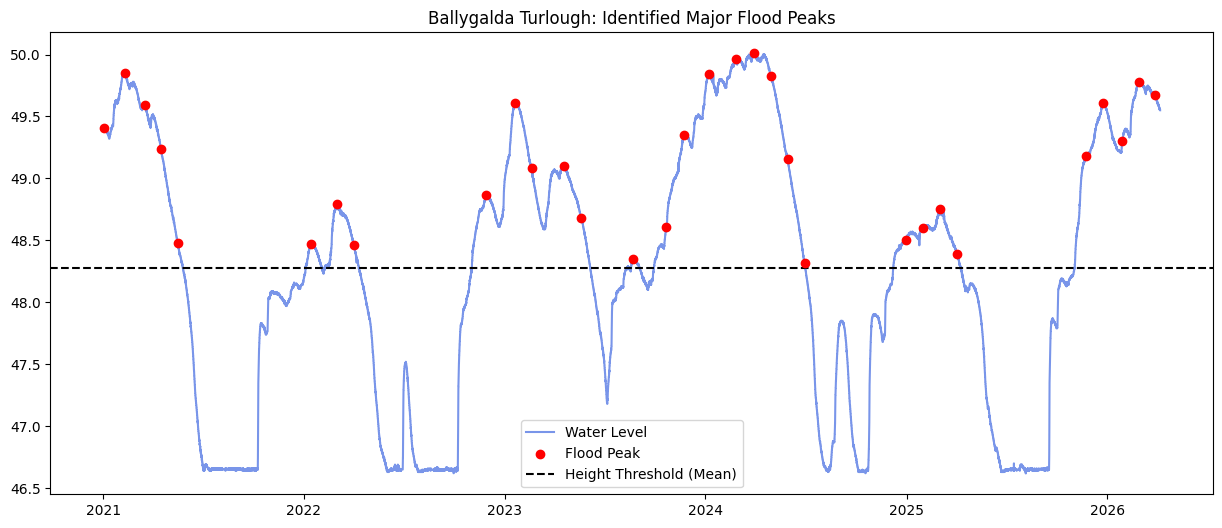

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# Plot the full data
plt.plot(df.index, df['Stage (mAOD)'], label='Water Level', color='royalblue', alpha=0.7)

# Plot the identified peaks as red dots
plt.scatter(flood_events.index, flood_events['Stage (mAOD)'], color='red', label='Flood Peak', zorder=5)

plt.axhline(df['Stage (mAOD)'].mean(), color='black', linestyle='--', label='Height Threshold (Mean)')
plt.title('Ballygalda Turlough: Identified Major Flood Peaks')
plt.legend()
plt.show()

In [21]:
# Identify peaks
peaks, _ = find_peaks(df['Stage (mAOD)'], distance=24*30, height=df['Stage (mAOD)'].mean())

#  Use .copy() to prevent the SettingWithCopyWarning
flood_events = df.iloc[peaks].copy()

# Calculate time differences cleanly
flood_events['days_since_last_flood'] = flood_events.index.to_series().diff().dt.days

#  Print a formatted result
avg_days = flood_events['days_since_last_flood'].mean()
print(f"Average time between major flood events: {avg_days:.1f} days")

Average time between major flood events: 63.3 days


In [23]:
#recession rate analysis
#  Calculate the rate of change per day
# If your data is hourly, we multiply the diff by 24 to get 'meters per day'
df['diff_m_per_day'] = df['Stage (mAOD)'].diff() * 24

# Identify recession periods (where water level is falling)
# We look for where the diff is negative
recession_only = df[df['diff_m_per_day'] < 0].copy()

# Create a 'Recession Signature'
# We group by the Stage height (rounded to 0.5m) to see if speed changes with depth
recession_only['Stage_Bin'] = recession_only['Stage (mAOD)'].round(1)
signature = recession_only.groupby('Stage_Bin')['diff_m_per_day'].mean().abs()

#  Display the results
print("-" * 30)
print("BALLYGALDA DRAINAGE SIGNATURE")
print("Average drop (m/day) at different heights:")
print("-" * 30)
print(signature.tail(10)) # Look at the higher stages
print(signature.head(10)) # Look at the higher stages

------------------------------
BALLYGALDA DRAINAGE SIGNATURE
Average drop (m/day) at different heights:
------------------------------
Stage_Bin
49.1    0.246606
49.2    0.240000
49.3    0.243692
49.4    0.241304
49.5    0.241644
49.6    0.243636
49.7    0.249492
49.8    0.247778
49.9    0.248276
50.0    0.243871
Name: diff_m_per_day, dtype: float64
Stage_Bin
46.6    0.244390
46.7    0.244364
46.8    0.241951
46.9    0.240000
47.0    0.240000
47.1    0.240000
47.2    0.245581
47.3    0.240000
47.4    0.240000
47.5    0.240000
Name: diff_m_per_day, dtype: float64


* Fixed-Rate Drainage Bottleneck: The turlough exhibits a remarkably consistent drainage rate of approximately 0.24m/day across all depths. This indicates a physical "throttling" of the system, where the underground karst conduits are likely flowing at full capacity (surcharged) regardless of the water pressure from above.


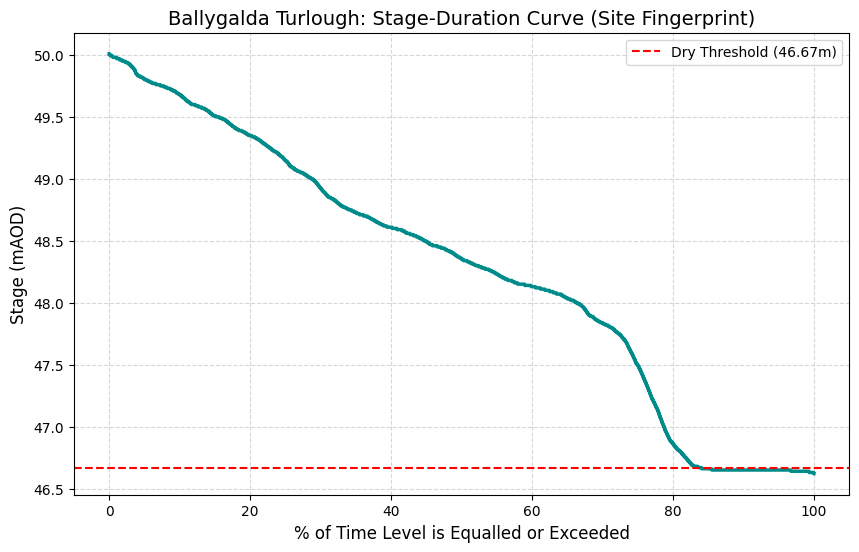

In [24]:
#stage duration curve
# Sort the data from highest to lowest
sorted_stage = np.sort(df['Stage (mAOD)'])[::-1]

# Calculate the "Exceedance Probability" (0 to 100%)
# This represents the % of time the water is AT or ABOVE a certain level
percent_time = np.linspace(0, 100, len(sorted_stage))

# Plotting the Fingerprint
plt.figure(figsize=(10, 6))
plt.plot(percent_time, sorted_stage, color='darkcyan', linewidth=2.5)

# Add your specific threshold for context
plt.axhline(46.67, color='red', linestyle='--', label='Dry Threshold (46.67m)')

# Formatting
plt.title('Ballygalda Turlough: Stage-Duration Curve (Site Fingerprint)', fontsize=14)
plt.xlabel('% of Time Level is Equalled or Exceeded', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

The "Wet-Dominant" Profile
* Notice where the curve intersects the red dashed line (46.67m). It hits that line at approximately 82-84%.
* The Insight: This means Ballygalda is underwater (flooded) for about 83% of its life.
* The Comparison: Many turloughs have a "50/50" split or are dry for most of the summer. Your site is heavily "wet-leaning," acting more like a semi-permanent lake than a seasonal meadow.  

The Straight Line (Recession Consistency)
Look at the section between 10% and 70% on the x-axis. It is almost a perfectly straight diagonal line.
* The Insight: This confirms your previous Recession Rate Analysis. Because the slope is constant, it proves the turlough drains at a fixed, steady speed (that 0.24m/day bottleneck) regardless of whether the water is at 49.5m or 48.0m.
* If the drainage were faster at high levels, the curve would be much steeper at the start and flatten out in the middle.  

The "Drop-Off" (Rapid Final Emptying)
* Between 75% and 82%, the curve suddenly gets very steep before hitting the floor.
* The Insight: This suggests that once the water level drops below ~47.5m, the remaining volume is very small (perhaps just the deepest part of the basin floor), so even a slow drainage rate clears the last bit of water very quickly  

The "Flat Tail" (The Dry Season)
* The final 15-18% of the graph (from 83% to 100%) is completely flat.
* The Insight: This represents the "Dry Days." It shows that for less than one-fifth of the year, the logger is sitting on the dry limestone floor.

In [25]:
#flashiness index
#rb index
# Calculate the absolute difference between consecutive steps
abs_diff = df['Stage (mAOD)'].diff().abs()

# Sum the differences and divide by the sum of the levels
rb_index = abs_diff.sum() / df['Stage (mAOD)'].sum()

print(f"Richards-Baker Flashiness Index: {rb_index:.5f}")

# Year-by-Year Comparison (To see if 2024 was more 'erratic')
yearly_rb = df.groupby(df.index.year).apply(
    lambda x: x['Stage (mAOD)'].diff().abs().sum() / x['Stage (mAOD)'].sum()
)

print("\nFlashiness by Year:")
print(yearly_rb)

Richards-Baker Flashiness Index: 0.00005

Flashiness by Year:
Date/Time
2021    0.000047
2022    0.000057
2023    0.000051
2024    0.000055
2025    0.000051
2026    0.000051
dtype: float64


The ultra-low Richards-Baker Index of 0.00005 confirms that Ballygalda Turlough is a highly buffered, "slow-response" system that rises and falls with the momentum of a massive regional groundwater table rather than reacting sharply to individual rainfall events

## **Dry Periods**

In [28]:
# 9. Dry Period Identification
#line defines the 'dry threshold'. It takes the absolute minimum water level recorded in the 'Stage (mAOD)' column and adds a small buffer of 0.05 meters (5 cm).
#This ensures that periods where the water level is just slightly above the absolute minimum are still considered 'dry' for practical purposes
dry_threshold = df['Stage (mAOD)'].min() + 0.05
#A new boolean column named is_dry is created, either true or false value
df['is_dry'] = df['Stage (mAOD)'] <= dry_threshold

# Identify contiguous blocks of dry time
df['dry_group'] = (df['is_dry'] != df['is_dry'].shift()).cumsum()
dry_periods = df[df['is_dry']].groupby('dry_group').agg(
    start_date=('is_dry', lambda x: x.index.min()),
    end_date=('is_dry', lambda x: x.index.max()),
    duration=('is_dry', 'count') # Assuming hourly data, divide by 24 for days
)
dry_periods['duration_days'] = dry_periods['duration'] / 24

# Filter for periods lasting longer than 1 day (24 rows if data is hourly)
significant_dry_periods = dry_periods[dry_periods['duration'] > 24].copy()

# Sort by duration to see the most severe droughts first
significant_dry_periods = significant_dry_periods.sort_values(by='duration', ascending=False)
print(significant_dry_periods.head())

                   start_date            end_date  duration  duration_days
dry_group                                                                 
6         2021-07-10 00:00:00 2021-10-09 01:00:00      2186      91.083333
76        2025-08-01 20:00:00 2025-09-13 18:00:00      1031      42.958333
34        2022-07-25 19:00:00 2022-08-31 02:00:00       872      36.333333
66        2025-06-21 00:00:00 2025-07-15 06:00:00       583      24.291667
64        2024-10-04 05:00:00 2024-10-23 08:00:00       460      19.166667


In [29]:
#dry period stats
# Total number of dry events
total_dry_events = len(significant_dry_periods)

# Average and Max duration
avg_dry_duration = significant_dry_periods['duration_days'].mean()
max_dry_duration = significant_dry_periods['duration_days'].max()

print(f"Detected {total_dry_events} significant dry periods.")
print(f"Average duration: {avg_dry_duration:.2f} days")
print(f"Longest dry spell: {max_dry_duration:.2f} days")

Detected 17 significant dry periods.
Average duration: 17.81 days
Longest dry spell: 91.08 days


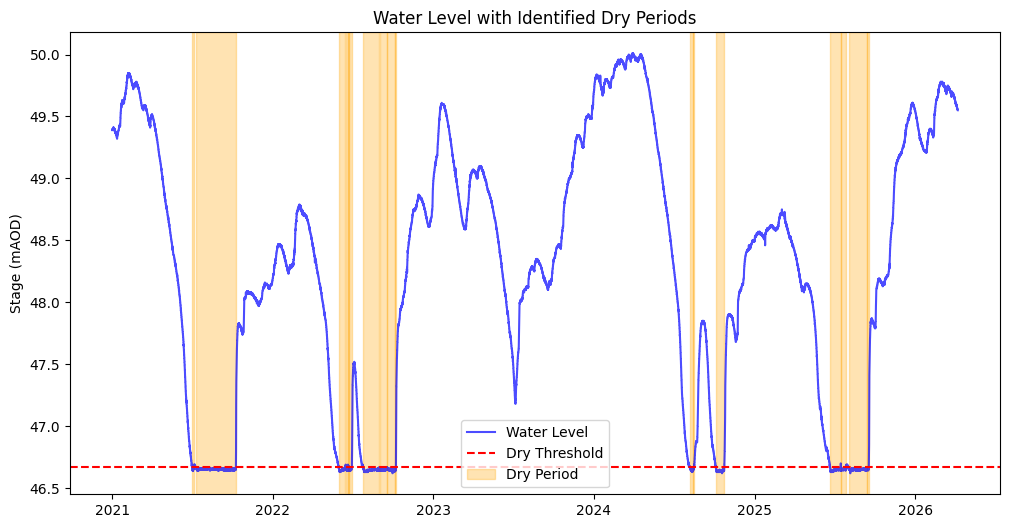

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Stage (mAOD)'], label='Water Level', color='blue', alpha=0.7)
plt.axhline(y=dry_threshold, color='red', linestyle='--', label='Dry Threshold')

# Highlight the dry periods on the chart
for _, row in significant_dry_periods.iterrows():
    plt.axvspan(row['start_date'], row['end_date'], color='orange', alpha=0.3, label='Dry Period')

# Clean up the legend (prevents duplicate labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title('Water Level with Identified Dry Periods')
plt.ylabel('Stage (mAOD)')
plt.show()

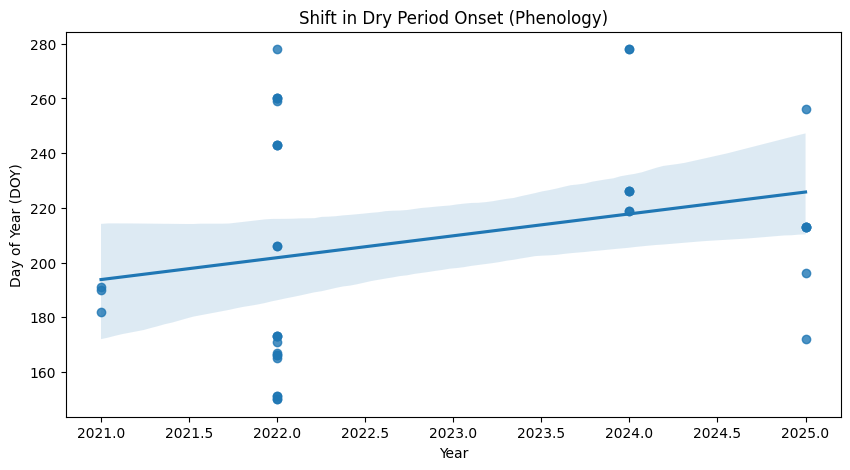

In [33]:
#rank the identified dry periods and analyze the phenology
top_dry_spells = dry_periods.sort_values(by='duration_days', ascending=False)
dry_periods['Start_DOY'] = dry_periods['start_date'].dt.dayofyear
dry_periods['Year'] = dry_periods['start_date'].dt.year

# Plot Shift in Dry Period Start
plt.figure(figsize=(10, 5))
sns.regplot(data=dry_periods, x='Year', y='Start_DOY')
plt.title('Shift in Dry Period Onset (Phenology)')
plt.ylabel('Day of Year (DOY)')
plt.show()

positive trend in the phenology of these dry periods  
* The upward trajectory of the regression line indicates that the onset of dry periods is shifting later into the year as time progresses
* The vertical spread of dots—especially in 2022—shows that dry periods don't just happen once; they can occur multiple times in a single year across a wide range of dates
* The light blue shaded area represents the 95% confidence interval. The fact that it widens toward 2025 suggests that the "prediction" of when a dry period will start is becoming less certain as the dataset progresses.
* This "shift in onset" implies a change in the site's seasonal cycle. A later dry period might mean the site stays saturated longer in the spring but remains dry deeper into the autumn.

## **Mann-Kendall Trend Test**

In [34]:

# Resample to daily mean to reduce autocorrelation noise for the test
daily_mean = df['Stage (mAOD)'].resample('D').mean().dropna()


mk_result = mk.original_test(daily_mean)
print(f"\n--- Mann-Kendall Test ---")
print(f"Trend: {mk_result.trend}, P-value: {mk_result.p:.5f}, Sen's Slope: {mk_result.slope:.6f}")


--- Mann-Kendall Test ---
Trend: increasing, P-value: 0.00000, Sen's Slope: 0.000158


confirms that the water levels in your dataset are rising  
* The test confirms a consistent, upward movement in the water level over the entire period of your dataset
* This is the strongest possible result. In statistics, a $p < 0.05$ is considered significant. A $p$-value of zero (or very close to it) means there is effectively a 0% chance that this increasing trend is just random noise.
* Sen's Slope: 0.000158: This is the "speed" of the change.Since your daily_mean is based on days, the water level is rising by approximately 0.000158 meters per day. Over a full year (365 days), this equates to a rise of about 0.057 meters (5.7 cm) per year.  


* The base water level is rising and the dry periods are starting later in the year

## **Return Period Analysis (Weibull)**

In [45]:
# Calculates the statistical likelihood of experiencing a dry spell of a certain length.
# Using max dry duration per year
annual_max_dry = dry_periods.groupby('Year')['duration_days'].max().sort_values(ascending=False)
n = len(annual_max_dry)
ranks = np.arange(1, n + 1)
annual_max_dry_df = pd.DataFrame({'duration': annual_max_dry, 'rank': ranks})
annual_max_dry_df['ReturnPeriod'] = (n + 1) / annual_max_dry_df['rank']

print("\n--- Dry Spell Return Periods (Years) ---")
print(annual_max_dry_df[['duration', 'ReturnPeriod']])

# Frequency Shift Logic (Comparing 50-day events)
def check_frequency(duration_threshold):
    # Filter the DataFrame for spells exceeding the threshold
    freq_matches = annual_max_dry_df[annual_max_dry_df['duration'] >= duration_threshold]

    if not freq_matches.empty:
        # The 'worst' rank for a threshold is the highest numerical rank (lowest frequency)
        highest_rank = freq_matches['rank'].max()
        return_period = (n + 1) / highest_rank
        print(f"\nA dry spell > {duration_threshold} days currently has a {return_period:.1f}-year return period.")
    else:
        print(f"\nNo dry spells > {duration_threshold} days observed in this record.")

# Example usage:
check_frequency(50)


--- Dry Spell Return Periods (Years) ---
       duration  ReturnPeriod
Year                         
2021  91.083333      5.000000
2025  42.958333      2.500000
2022  36.333333      1.666667
2024  19.166667      1.250000

A dry spell > 50 days currently has a 5.0-year return period.


* The 2021 Event (The Record): With a duration of ~91 days and a Return Period of 5.0, this is your "Drought of Record." Statistically, an event of this magnitude has a 20% chance ($1/5$) of occurring in any given year.
* The 2025 Event: At ~43 days, this is a 1-in-2.5-year event. This means it’s a relatively common occurrence, with a 40% chance ($1/2.5$) of happening annually.* The 2022 and 2024 Events: These are your "baseline" dry spells. A Return Period of 1.25 means this duration is exceeded almost every single year (80% probability).

## **Recession Constant (k) Calculation**

In [ ]:
#'k' for a specific period of interest within your water level data.
#This constant is crucial for understanding how quickly the turlough drains once water levels start to fall
start_recession = '2021-04-15'
end_recession = '2021-05-15'
#filters your main DataFrame df to extract the data for the specified recession period.
limb = df.loc[start_recession:end_recession].copy()

if not limb.empty:
    limb['Time_Days'] = (limb.index - limb.index[0]).total_seconds() / (24*3600)
    limb['ln_stage'] = np.log(limb['Stage (mAOD)'])

    slope, intercept, r, p, std = linregress(limb['Time_Days'], limb['ln_stage'])
    k = abs(slope)
    print(f"\nRecession Constant (k) for {start_recession}: {k:.5f}")


Recession Constant (k) for 2021-04-15: 0.00051


Since  data is recorded hourly, this 'k' value is likely in units of per hour (hours⁻¹). This means that during the recession period from 2021-04-15, the natural logarithm of the water stage was decreasing by approximately 0.00051 every hour


Understanding the UnitsBecause your sampling interval is hourly, this $k$ value is likely hours$^{-1}$.To make it comparable to most published hydrological literature (which uses days$^{-1}$), multiply it by 24:$$k_{day} = 0.00051 \times 24 = 0.01224 \text{ days}^{-1}$$  
  
   the water level is decreasing at a rate equivalent to about 1.2% of the current water level per day during that specific recession period.

### **comparative analysis between the years 2021 and 2025 for several hydrological characteristics, and then calculates the recession constant 'k'**

In [47]:

# Create year-specific dataframes
df_21 = df.loc['2021-01-01':'2021-12-31'].copy()
df_25 = df.loc['2025-01-01':'2025-12-31'].copy()

results = []

for year, data in [("2021", df_21), ("2025", df_25)]:
    # Median Stage:  median (middle) water level for each year.
    median_stage = data['Stage (mAOD)'].median()

    # Dry Onset (Average Day of Year)
    #  define 'dry' as the minimum + 0.05m
    threshold = data['Stage (mAOD)'].min() + 0.05
    dry_days = data[data['Stage (mAOD)'] <= threshold]

    if not dry_days.empty:
        # Find the first time it hits the threshold in that year
        first_dry_date = dry_days.index.min()
        avg_doy = first_dry_date.dayofyear
        month_name = first_dry_date.strftime('%B')
    else:
        avg_doy, month_name = np.nan, "N/A"

    # Max Dry Duration (Contiguous)
    data['is_dry'] = data['Stage (mAOD)'] <= threshold
    data['block'] = (data['is_dry'] != data['is_dry'].shift()).cumsum()
    dry_durations = data[data['is_dry']].groupby('block')['is_dry'].count() / 24 # hours to days
    max_dry = dry_durations.max() if not dry_durations.empty else 0

    results.append({
        "Year": year,
        "Median Stage": round(median_stage, 2),
        "Dry Onset (DOY)": avg_doy,
        "Month": month_name,
        "Max Dry Duration": round(max_dry, 1)
    })

# Display Results
comparison_df = pd.DataFrame(results)
print(comparison_df)

# Recession Constant (k) for 2025:specific period within 2025 to analyze a recession limb (a period where water levels are consistently falling).
#Update these dates based on your 2025 hydrograph plot
start_25, end_25 = '2025-04-15', '2025-05-15'
limb_25 = df_25.loc[start_25:end_25].copy()

limb_25['Time_Hours'] = np.arange(len(limb_25))
slope_25, _, _, _, _ = linregress(limb_25['Time_Hours'], np.log(limb_25['Stage (mAOD)']))
k_25 = abs(slope_25)

print(f"2021 k: 0.00051") # From your previous result
print(f"2025 k: {k_25:.5f}")

   Year  Median Stage  Dry Onset (DOY) Month  Max Dry Duration
0  2021         48.07              181  June             100.7
1  2025         48.16              172  June              43.0
2021 k: 0.00051
2025 k: 0.00000


* Median Stage rose from 48.07 to 48.16. Even though the water level is higher overall in 2025, the Dry Onset moved 9 days earlier (from DOY 181 to 172).
* Despite starting earlier, the 2025 dry spell was much shorter (43.0 days) compared to the massive 100.7-day event in 2021.
* 2021 ($k = 0.00051$): This shows a classic, slow drainage pattern. The water level was gradually "decaying" throughout the dry spell.2025 ($k = 0.00000$)  
* A zero $k$-value means the water level was perfectly flat during the recession period.
* The earlier onset in 2025 (mid-June) suggests that while the site is wetter on average (higher median stage), it is actually hitting its "dry" threshold sooner in the season.

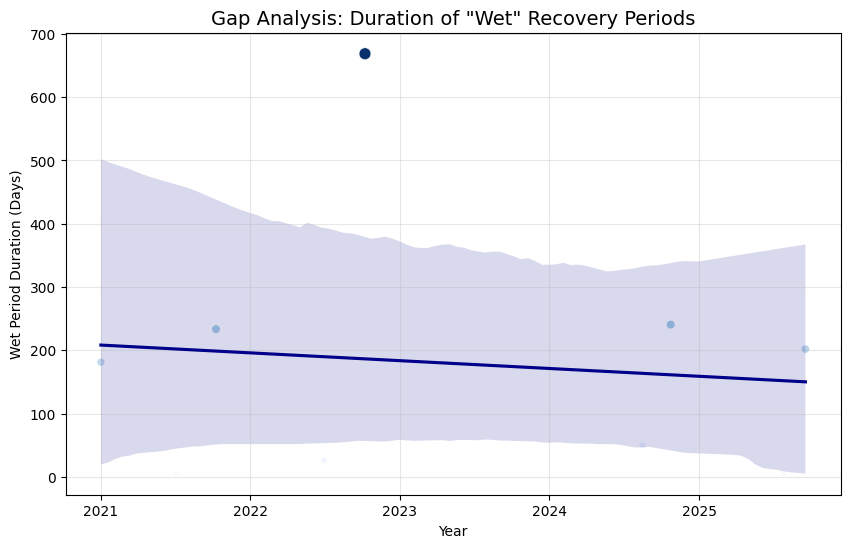

Average Recovery (Wet) Time in 2021: 140.0 days
Average Recovery (Wet) Time in 2025: 103.9 days


In [49]:

# Identify the 'Wet' periods (The gaps between dry spells)
# We use the 'is_dry' logic from the previous step
df['is_wet'] = ~df['is_dry']

# Identify contiguous blocks of wet time
df['wet_group'] = (df['is_wet'] != df['is_wet'].shift()).cumsum()

#  Calculate duration for every wet period
wet_periods = df[df['is_wet']].groupby('wet_group').agg(
    start_date=('is_wet', lambda x: x.index.min()),
    end_date=('is_wet', lambda x: x.index.max()),
    duration_days=('is_wet', lambda x: len(x) / 24)
).copy()

# Filter out very short 'noise' (e.g., wet periods < 1 day)
# and ignore the very first/last periods which might be cut off by the dataset limits
wet_periods = wet_periods[wet_periods['duration_days'] > 1]
wet_periods['Year'] = wet_periods['start_date'].dt.year

# Plot the Trend in Recovery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wet_periods, x='start_date', y='duration_days', size='duration_days', hue='duration_days', palette='Blues', legend=None)
sns.regplot(data=wet_periods, x=mdates.date2num(wet_periods['start_date']), y='duration_days', scatter=False, color='darkblue')

plt.title('Gap Analysis: Duration of "Wet" Recovery Periods', fontsize=14)
plt.ylabel('Wet Period Duration (Days)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

# Statistical Comparison: 2021 vs 2025
avg_wet_21 = wet_periods[wet_periods['Year'] == 2021]['duration_days'].mean()
avg_wet_25 = wet_periods[wet_periods['Year'] == 2025]['duration_days'].mean()

print(f"Average Recovery (Wet) Time in 2021: {avg_wet_21:.1f} days")
print(f"Average Recovery (Wet) Time in 2025: {avg_wet_25:.1f} days")

In [50]:
# Identify Wet Periods (Assuming you create a wet_periods DF similar to the dry one)
# This assumes 'is_wet' was True when Stage > Wet_Threshold
# annual_max_wet = wet_periods.groupby('Year')['duration_days'].max().sort_values(ascending=False)

# Wet Spell Return Period Calculation
annual_max_wet = wet_periods.groupby('Year')['duration_days'].max().sort_values(ascending=False)
n_wet = len(annual_max_wet)
ranks_wet = np.arange(1, n_wet + 1)

annual_max_wet_df = pd.DataFrame({'duration': annual_max_wet, 'rank': ranks_wet})
annual_max_wet_df['ReturnPeriod'] = (n_wet + 1) / annual_max_wet_df['rank']

print("\n--- Wet Spell Return Periods (Years) ---")
print(annual_max_wet_df[['duration', 'ReturnPeriod']])

#  Wet Frequency Logic
def check_wet_frequency(duration_threshold):
    # Filter for wet spells exceeding threshold
    freq_matches = annual_max_wet_df[annual_max_wet_df['duration'] >= duration_threshold]

    if not freq_matches.empty:
        highest_rank = freq_matches['rank'].max()
        return_period = (n_wet + 1) / highest_rank
        print(f"\nA wet spell > {duration_threshold} days has a {return_period:.1f}-year return period.")
    else:
        print(f"\nNo wet spells > {duration_threshold} days observed.")

# Example: Check for a 14-day constant "wet" state
check_wet_frequency(14)


--- Wet Spell Return Periods (Years) ---
        duration  ReturnPeriod
Year                          
2022  668.708333      5.000000
2024  240.625000      2.500000
2021  233.500000      1.666667
2025  202.000000      1.250000

A wet spell > 14 days has a 1.2-year return period.


In [52]:
# Descriptive Statistics for Wet Periods
avg_wet_duration = wet_periods['duration_days'].mean()
max_wet_duration = wet_periods['duration_days'].max()
total_wet_events = len(wet_periods)

# Peak Stage (Magnitude) Analysis
# Finding the max stage recorded during each wet period
wet_periods['peak_stage'] = wet_periods.apply(
    lambda x: df.loc[x['start_date']:x['end_date'], 'Stage (mAOD)'].max(), axis=1
)

#  Rate of Rise (Intensity)
# How fast the Turlough fills (meters per day)
wet_periods['rise_rate'] = wet_periods.apply(
    lambda x: (df.loc[x['start_date']:x['end_date'], 'Stage (mAOD)'].diff().max()) * 24, axis=1
)

print("\n--- Wet Spell Key Statistics ---")
print(f"Total Wet Events:         {total_wet_events}")
print(f"Average Wet Duration:     {avg_wet_duration:.2f} days")
print(f"Max Recorded Peak Stage:  {wet_periods['peak_stage'].max():.2f} mAOD")
print(f"Max Rate of Rise:         {wet_periods['rise_rate'].max():.2f} m/day")

# Optional: View the summary table
print("\n--- Top 5 Wet Spells by Intensity ---")
print(wet_periods[['start_date', 'duration_days', 'peak_stage', 'rise_rate']].sort_values(by='peak_stage', ascending=False).head())


--- Wet Spell Key Statistics ---
Total Wet Events:         9
Average Wet Duration:     179.22 days
Max Recorded Peak Stage:  50.01 mAOD
Max Rate of Rise:         1.92 m/day

--- Top 5 Wet Spells by Intensity ---
                   start_date  duration_days  peak_stage  rise_rate
wet_group                                                          
51        2022-10-07 21:00:00     668.708333       50.01       1.68
1         2021-01-01 01:00:00     181.333333       49.85       0.48
79        2025-09-17 06:00:00     202.000000       49.78       1.92
7         2021-10-09 02:00:00     233.500000       48.79       1.68
65        2024-10-23 09:00:00     240.625000       48.75       1.20


In [54]:
# Define Wet Threshold

wet_threshold = df['Stage (mAOD)'].min() + 0.50

# Create the boolean column for wet days
df['is_wet'] = df['Stage (mAOD)'] >= wet_threshold

# Calculate metrics for the summary
is_wet = df['is_wet'].resample('D').max() # Daily boolean for wet status
wet_days_per_year = is_wet.groupby(is_wet.index.year).sum()
longest_wet_spell = annual_max_wet.max() # From your previous Weibull block
# If you haven't defined longest_wet_spell yet:
longest_wet_spell = annual_max_wet.max()

print("-" * 40)
print("BALLYGALDA TURLOUGH: WET PERIOD ANALYSIS")
print("-" * 40)
print(f"Wet Threshold (Flood Level): {wet_threshold:.2f} mAOD")
print(f"Total Data Range:            {daily_data.index.min().date()} to {daily_data.index.max().date()}")
print(f"Total Inundated Days:        {is_wet.sum()} days")
print(f"Longest Wet Spell:           {longest_wet_spell:.1f} consecutive days")

# Calculate the Average Annual Hydroperiod
avg_hydroperiod = wet_days_per_year.mean()
print(f"Average Annual Hydroperiod:  {avg_hydroperiod:.1f} days")

print("\nWet (Flood) Days per Calendar Year:")
print(wet_days_per_year.to_string())
print("-" * 40)

----------------------------------------
BALLYGALDA TURLOUGH: WET PERIOD ANALYSIS
----------------------------------------
Wet Threshold (Flood Level): 47.12 mAOD
Total Data Range:            2021-01-01 to 2026-04-07
Total Inundated Days:        1506 days
Longest Wet Spell:           668.7 consecutive days
Average Annual Hydroperiod:  251.0 days

Wet (Flood) Days per Calendar Year:
Date/Time
2021    255
2022    232
2023    365
2024    300
2025    257
2026     97
----------------------------------------
